# LangGraph Agentic RAG 튜토리얼

이 노트북은 LangGraph를 사용하여 **자기 교정(Self-Correction)** 기능이 있는 RAG 에이전트를 구축합니다.

**워크플로우:**
1. 사용자 질문 → LLM이 검색 필요 여부 판단
2. 필요시 벡터스토어 검색
3. 검색된 문서의 관련성 평가 (`GRADE_PROMPT`)
4. 관련 없으면 질문 재작성 후 재검색 (`REWRITE_PROMPT`)
5. 관련 있으면 답변 생성 (`GENERATE_PROMPT`)

## 0단계: 환경 설정

In [19]:
import os
import warnings
from typing import Literal
from dotenv import load_dotenv
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel, Field

warnings.filterwarnings("ignore", message="Pydantic serializer warnings")

load_dotenv()

True

## 1단계: 문서 로드 및 전처리

Lilian Weng의 블로그 포스트 3개를 로드하고 청크로 분할합니다.

In [20]:
urls = [
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/",
    "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100,
    chunk_overlap=50,
)
doc_splits = text_splitter.split_documents(docs_list)

print(f"로드된 문서 수: {len(docs_list)}")
print(f"분할 후 청크 수: {len(doc_splits)}")

로드된 문서 수: 3
분할 후 청크 수: 538


## 2단계: 벡터 저장소 및 검색 도구 생성

분할된 문서를 벡터 저장소에 저장하고, LangGraph에서 사용할 검색 도구를 정의합니다.

In [21]:
vectorstore = InMemoryVectorStore.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings(),
)
retriever = vectorstore.as_retriever()


@tool
def retrieve_blog_posts(query: str) -> str:
    """Search and return information about Lilian Weng blog posts."""
    docs = retriever.invoke(query)
    return "\n\n".join([doc.page_content for doc in docs])


retriever_tool = retrieve_blog_posts
print("검색 도구 생성 완료: retrieve_blog_posts")

검색 도구 생성 완료: retrieve_blog_posts


## 3단계: 프롬프트 및 모델 정의

문서 평가, 질문 재작성, 답변 생성에 사용할 프롬프트 템플릿과 모델을 정의합니다.

In [22]:
# 문서 관련성 평가 프롬프트
# (당신은 검색된 문서가 사용자 질문과 관련 있는지 평가하는 채점자입니다.
#  검색된 문서와 사용자 질문을 받아서, 문서에 질문과 관련된 키워드나 의미가 포함되어 있으면
#  관련 있다고 판단합니다. 'yes' 또는 'no'의 이진 점수를 반환합니다.)
GRADE_PROMPT = (
    "You are a grader assessing relevance of a retrieved document to a user question. \n "
    "Here is the retrieved document: \n\n {context} \n\n"
    "Here is the user question: {question} \n"
    "If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n"
    "Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."
)

# 질문 재작성 프롬프트
# (입력을 살펴보고 근본적인 의미/의도를 파악하세요.
#  초기 질문을 받아서 개선된 질문을 작성합니다.)
REWRITE_PROMPT = (
    "Look at the input and try to reason about the underlying semantic intent / meaning.\n"
    "Here is the initial question:"
    "\n ------- \n"
    "{question}"
    "\n ------- \n"
    "Formulate an improved question:"
)

# 답변 생성 프롬프트
# (당신은 질문 답변 어시스턴트입니다. 검색된 컨텍스트를 사용하여 질문에 답변하세요.
#  답을 모르면 모른다고 말하세요. 최대 3문장으로 간결하게 답변하세요.)
GENERATE_PROMPT = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question} \n"
    "Context: {context}"
)

# 모델 초기화 (response_model, grader_model 분리)
response_model = init_chat_model("gpt-4.1", temperature=0)
grader_model = init_chat_model("gpt-4.1", temperature=0)

print("프롬프트 및 모델 정의 완료")

프롬프트 및 모델 정의 완료


## 4단계: 에이전트 노드 정의

LangGraph의 각 노드를 정의합니다:
- `generate_query_or_respond`: 검색 필요 여부 판단
- `grade_documents`: 검색된 문서의 관련성 평가
- `rewrite_question`: 질문 재작성
- `generate_answer`: 최종 답변 생성

In [23]:
# 문서 관련성 평가를 위한 구조화된 출력
class GradeDocuments(BaseModel):
    """Grade documents using a binary score for relevance check."""
    binary_score: str = Field(
        description="Relevance score: 'yes' if relevant, or 'no' if not relevant"
    )


# 노드 1: 쿼리 생성 또는 직접 응답
def generate_query_or_respond(state: MessagesState):
    """Call the model to generate a response based on the current state."""
    response = (
        response_model
        .bind_tools([retriever_tool])
        .invoke(state["messages"])
    )
    return {"messages": [response]}


# 노드 2: 문서 관련성 평가
def grade_documents(
    state: MessagesState,
) -> Literal["generate_answer", "rewrite_question"]:
    """Determine whether the retrieved documents are relevant to the question."""
    question = state["messages"][0].content
    context = state["messages"][-1].content

    prompt = GRADE_PROMPT.format(question=question, context=context)
    response = (
        grader_model
        .with_structured_output(GradeDocuments)
        .invoke([{"role": "user", "content": prompt}])
    )
    score = response.binary_score

    if score == "yes":
        print("  → 문서 평가: 관련 있음 → 답변 생성")
        return "generate_answer"
    else:
        print("  → 문서 평가: 관련 없음 → 질문 재작성")
        return "rewrite_question"


# 노드 3: 질문 재작성
def rewrite_question(state: MessagesState):
    """Rewrite the original user question."""
    messages = state["messages"]
    question = messages[0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    print(f"  → 질문 재작성: {response.content}")
    return {"messages": [HumanMessage(content=response.content)]}


# 노드 4: 답변 생성
def generate_answer(state: MessagesState):
    """Generate an answer."""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}


print("노드 정의 완료")

노드 정의 완료


## 5단계: 그래프 조립

정의한 노드들을 LangGraph 워크플로우로 연결합니다.

```
START → generate_query_or_respond → (도구 호출?) → retrieve → grade_documents
                                        ↓                         ↓          ↓
                                       END              generate_answer  rewrite_question
                                                              ↓               ↓
                                                             END    generate_query_or_respond (재시도)
```

In [24]:
workflow = StateGraph(MessagesState)

# 노드 추가
workflow.add_node(generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retriever_tool]))
workflow.add_node(rewrite_question)
workflow.add_node(generate_answer)

# 엣지 연결
workflow.add_edge(START, "generate_query_or_respond")
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {"tools": "retrieve", END: END},
)
workflow.add_conditional_edges("retrieve", grade_documents)
workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

graph = workflow.compile()

print("그래프 조립 완료!")

그래프 조립 완료!


## 6단계: 그래프 시각화

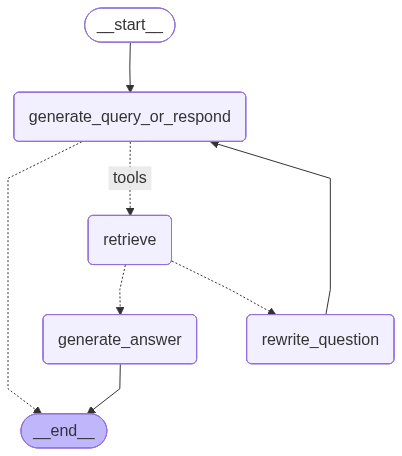

In [25]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 7단계: 에이전트 실행

스트리밍 방식으로 실행하여 각 노드의 업데이트를 순서대로 확인합니다.

In [26]:
# Lilian Weng의 보상 해킹 유형에 대해 질문
for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",  # Lilian Weng은 보상 해킹의 유형에 대해 뭐라고 말하는가?
            }
        ]
    }
):
    for node, update in chunk.items():
        print(f"Update from node: {node}")
        update["messages"][-1].pretty_print()
        print("\n")

Update from node: generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_UM5jox13iQtCHPRkoQjLBF4C)
 Call ID: call_UM5jox13iQtCHPRkoQjLBF4C
  Args:
    query: types of reward hacking


  → 문서 평가: 관련 있음 → 답변 생성
Update from node: retrieve
================================= Tool Message =================================
Name: retrieve_blog_posts

Detecting Reward Hacking#

In-Context Reward Hacking#

(Note: Some work defines reward tampering as a distinct category of misalignment behavior from reward hacking. But I consider reward hacking as a broader concept here.)
At a high level, reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering.

Why does Reward Hacking Exist?#


Update from node: generate_answer
================================== Ai Message ==================================

Lilian Weng categorizes reward hacking into two types: environ